<a href="https://colab.research.google.com/github/Hiraeth-mist/ML-GTEX-Muscle-aging-biomarker-prediction/blob/main/notebooks/03_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Visualization of Differential Expression

## Objective

This notebook visualizes age-associated transcriptional changes across three skeletal muscle types:

* Extensor Digitorum Longus (EDL)
* Soleus
* Tibialis Anterior (TA)

Differentially expressed genes identified in Notebook 02 are explored using volcano plots and summary visualizations.

## Biological Questions

* How extensive are aging-associated gene expression changes in each muscle type?
* Which muscles exhibit the strongest transcriptional response to aging?
* Are aging-associated changes primarily driven by upregulated or downregulated genes?

## Deliverables

### Figure 4

EDL Volcano Plot

### Figure 5

Soleus Volcano Plot

### Figure 6

TA Volcano Plot


### Outputs

* EDL Volcano Plot
* Soleus Volcano Plot
* TA Volcano Plot
* DEG Summary Statistics
* Publication-ready figures for report and poster

## Expected Outcome

Visualization of the magnitude and direction of age-associated gene expression changes across different skeletal muscle types.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
install.packages(c(
  "ggplot2",
  "pheatmap"
))

if (!requireNamespace("BiocManager", quietly = TRUE))
  install.packages("BiocManager")

BiocManager::install(c(
  "DESeq2"
))

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com

Bioconductor version 3.23 (BiocManager 1.30.27), R 4.6.0 (2026-04-24)

Installing package(s) 'BiocVersion', 'DESeq2'

also installing the dependencies ‘XVector’, ‘formatR’, ‘abind’, ‘SparseArray’, ‘lambda.r’, ‘futile.options’, ‘Seqinfo’, ‘S4Arrays’, ‘DelayedArray’, ‘futile.logger’, ‘snow’, ‘BH’, ‘S4Vectors’, ‘IRanges’, ‘GenomicRanges’, ‘SummarizedExperiment’, ‘BiocGenerics’, ‘Biobase’, ‘BiocParallel’, ‘matrixStats’, ‘locfit’, ‘MatrixGenerics’, ‘RcppArmadillo’


Old packages: 'callr', 'pak', 'sessioninfo', 'xtable'



In [2]:
library(DESeq2)
library(ggplot2)
library(pheatmap)

Loading required package: S4Vectors

Loading required package: stats4

Loading required package: BiocGenerics

Loading required package: generics


Attaching package: ‘generics’


The following objects are masked from ‘package:base’:

    as.difftime, as.factor, as.ordered, intersect, is.element, setdiff,
    setequal, union



Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, is.unsorted, lapply, Map, mapply, match, mget,
    order, paste, pmax, pmax.int, pmin, pmin.int, Position, rank,
    rbind, Reduce, rownames, sapply, saveRDS, table, tapply, unique,
    unsplit, which.max, which.min



Attaching package: ‘S4Vectors’


The following object is masked from ‘package:utils’:

    findMatches


The follo

In [3]:
dds <- readRDS(
"/content/drive/MyDrive/aging-muscle-transcriptomics-case-study/data/processed/dds.rds"
)

In [6]:
res_edl_df <- read.csv(
"/content/drive/MyDrive/aging-muscle-transcriptomics-case-study/results/EDL_DE_results.csv"
)

res_sol_df <- read.csv(
"/content/drive/MyDrive/aging-muscle-transcriptomics-case-study/results/SOL_DE_results.csv"
)

res_ta_df <- read.csv(
"/content/drive/MyDrive/aging-muscle-transcriptomics-case-study/results/TA_DE_results.csv"
)

In [7]:
head(
  res_edl_df[
    order(res_edl_df$padj),
  ],
  20
)

,X,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
7525,ENSMUSG00000038658,286.94991,-1.955442,0.1940774,-10.075577,7.084357e-24,5.746122e-20
8252,ENSMUSG00000042045,251.65086,2.369070,0.2422338,9.780096,1.370811e-22,5.559323e-19
7257,ENSMUSG00000037685,514.14503,-1.823665,0.1942986,-9.385892,6.238626e-21,1.686716e-17
3222,ENSMUSG00000024803,1183.39592,1.883557,0.2043749,9.216186,3.078570e-20,6.242569e-17
2817,ENSMUSG00000023067,175.22407,2.749553,0.3119309,8.814622,1.200891e-18,1.948086e-15
9846,ENSMUSG00000058230,93.63909,-2.813004,0.3306341,-8.507906,1.771020e-17,2.394124e-14
2940,ENSMUSG00000024048,3870.50236,1.384215,0.1720845,8.043811,8.708666e-16,1.009086e-12
373,ENSMUSG00000003031,107.44415,-2.585254,0.3238408,-7.983102,1.427011e-15,1.446811e-12
4332,ENSMUSG00000027763,3495.18960,-1.337038,0.1725883,-7.746979,9.410472e-15,8.480927e-12


In [8]:
head(
  res_sol_df[
    order(res_sol_df$padj),
  ],
  20
)

,X,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
8158,ENSMUSG00000041559,442.309250,2.933006,0.3025754,9.693472,3.214134e-22,3.675040e-18
4846,ENSMUSG00000028989,264.223411,2.753140,0.3083732,8.927945,4.339935e-19,2.481141e-15
5862,ENSMUSG00000031849,111.849533,2.673197,0.3080039,8.679102,3.989054e-18,1.520362e-14
7631,ENSMUSG00000039084,134.121195,2.563419,0.3104209,8.257881,1.482811e-16,4.238614e-13
10895,ENSMUSG00000075376,236.733895,-2.211429,0.2817254,-7.849592,4.173933e-15,9.544950e-12
5358,ENSMUSG00000030433,682.566918,1.536101,0.2010494,7.640415,2.165227e-14,4.126202e-11
10815,ENSMUSG00000074264,532.737960,1.430882,0.2287355,6.255615,3.959515e-10,6.467585e-07
8064,ENSMUSG00000040966,68.817223,2.188448,0.3951377,5.538445,3.051693e-08,4.361632e-05
5924,ENSMUSG00000031994,43.052522,-2.679436,0.4858260,-5.515217,3.483505e-08,4.425600e-05


In [9]:
head(
  res_ta_df[
    order(res_ta_df$padj),
  ],
  20
)

,X,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2808,ENSMUSG00000023043,51.20510,5.3221745,0.6068947,8.769519,1.794319e-18,1.613273e-14
6561,ENSMUSG00000034361,92.80846,3.3023150,0.3968883,8.320514,8.758258e-17,3.937275e-13
8604,ENSMUSG00000044768,38.37450,4.1366758,0.5082373,8.139261,3.976989e-16,1.191904e-12
9962,ENSMUSG00000059741,460.31386,-1.5932074,0.2049990,-7.771782,7.738973e-15,1.739528e-11
10297,ENSMUSG00000063821,116.33523,2.0568722,0.2681346,7.671045,1.706011e-14,3.067749e-11
5366,ENSMUSG00000030470,110.40206,-2.9463053,0.4117446,-7.155662,8.326982e-13,1.247798e-09
10853,ENSMUSG00000074800,21.08246,4.6085425,0.6883602,6.694958,2.157334e-11,2.770941e-08
6972,ENSMUSG00000036390,56.40737,2.4516723,0.3693531,6.637747,3.185147e-11,3.579707e-08
6316,ENSMUSG00000033196,2744.73470,-1.8807839,0.2845865,-6.608830,3.873702e-11,3.869829e-08


In [10]:
top20_edl <- head(
  res_edl_df[order(res_edl_df$padj), ],
  20
)

top20_sol <- head(
  res_sol_df[order(res_sol_df$padj), ],
  20
)

top20_ta <- head(
  res_ta_df[order(res_ta_df$padj), ],
  20
)

write.csv(
  top20_edl,
  "/content/drive/MyDrive/aging-muscle-transcriptomics-case-study/results/tables/Top20_EDL.csv",
  row.names = FALSE
)

write.csv(
  top20_sol,
  "/content/drive/MyDrive/aging-muscle-transcriptomics-case-study/results/tables/Top20_Soleus.csv",
  row.names = FALSE
)

write.csv(
  top20_ta,
  "/content/drive/MyDrive/aging-muscle-transcriptomics-case-study/results/tables/Top20_TA.csv",
  row.names = FALSE
)

In [11]:
if (!requireNamespace("BiocManager", quietly = TRUE))
    install.packages("BiocManager")

BiocManager::install("EnhancedVolcano")

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com

Bioconductor version 3.23 (BiocManager 1.30.27), R 4.6.0 (2026-04-24)

Installing package(s) 'EnhancedVolcano'

also installing the dependency ‘ggrepel’


Old packages: 'callr', 'pak', 'sessioninfo', 'xtable'



In [12]:
library(EnhancedVolcano)

Loading required package: ggrepel



Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
ℹ The deprecated feature was likely used in the EnhancedVolcano package.
  Please report the issue to the authors.”
Warning message:
“The `size` argument of `element_line()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.
ℹ The deprecated feature was likely used in the EnhancedVolcano package.
  Please report the issue to the authors.”


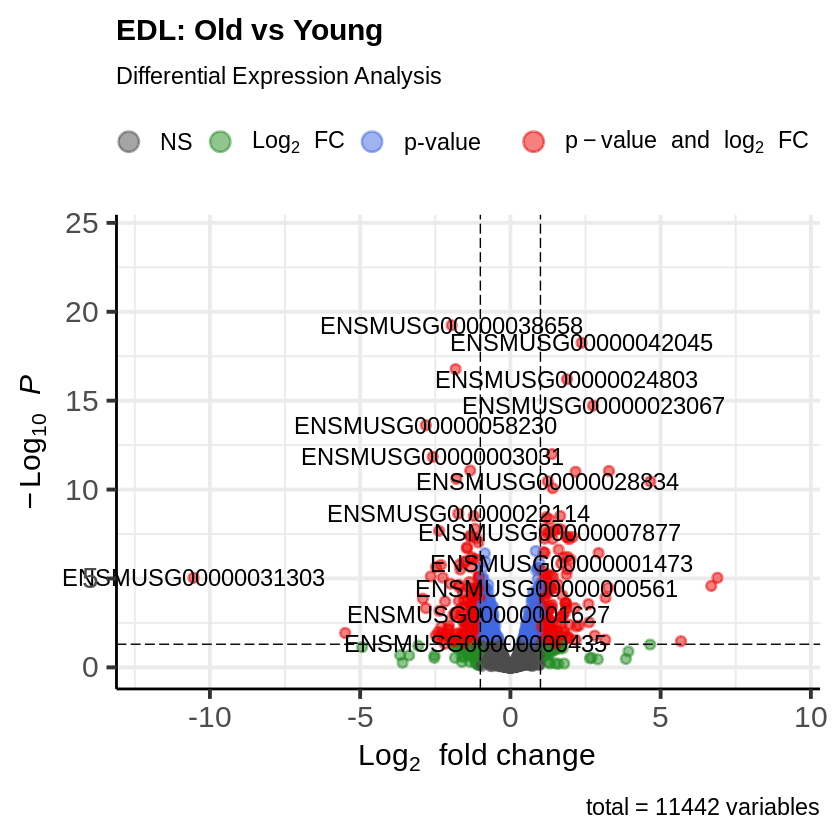

In [13]:
EnhancedVolcano(
    res_edl_df,
    lab = res_edl_df$X,
    x = "log2FoldChange",
    y = "padj",
    pCutoff = 0.05,
    FCcutoff = 1,
    title = "EDL: Old vs Young",
    subtitle = "Differential Expression Analysis"
)

In [16]:
png(
"/content/drive/MyDrive/aging-muscle-transcriptomics-case-study/results/volcano/EDL_volcano.png",
width = 2200,
height = 1800,
res = 300
)

EnhancedVolcano(
    res_edl_df,
    lab = res_edl_df$X,
    x = "log2FoldChange",
    y = "padj",
    pCutoff = 0.05,
    FCcutoff = 1,
    title = "EDL: Old vs Young"
)

dev.off()

agg_record_cf6688631b6 
                     2

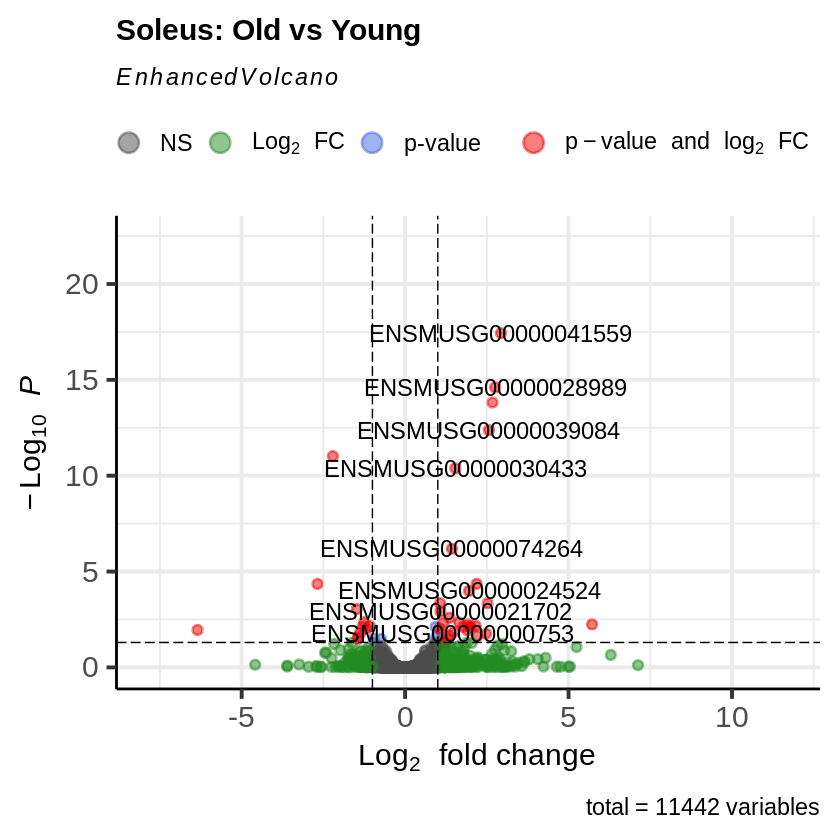

In [17]:
EnhancedVolcano(
    res_sol_df,
    lab = res_sol_df$X,
    x = "log2FoldChange",
    y = "padj",
    pCutoff = 0.05,
    FCcutoff = 1,
    title = "Soleus: Old vs Young"
)

In [18]:
png(
"/content/drive/MyDrive/aging-muscle-transcriptomics-case-study/results/volcano/Soleus_volcano.png",
width = 2200,
height = 1800,
res = 300
)

EnhancedVolcano(
    res_sol_df,
    lab = res_sol_df$X,
    x = "log2FoldChange",
    y = "padj",
    pCutoff = 0.05,
    FCcutoff = 1,
    title = "Soleus: Old vs Young"
)

dev.off()

agg_record_cf6b92ee2e 
                    2

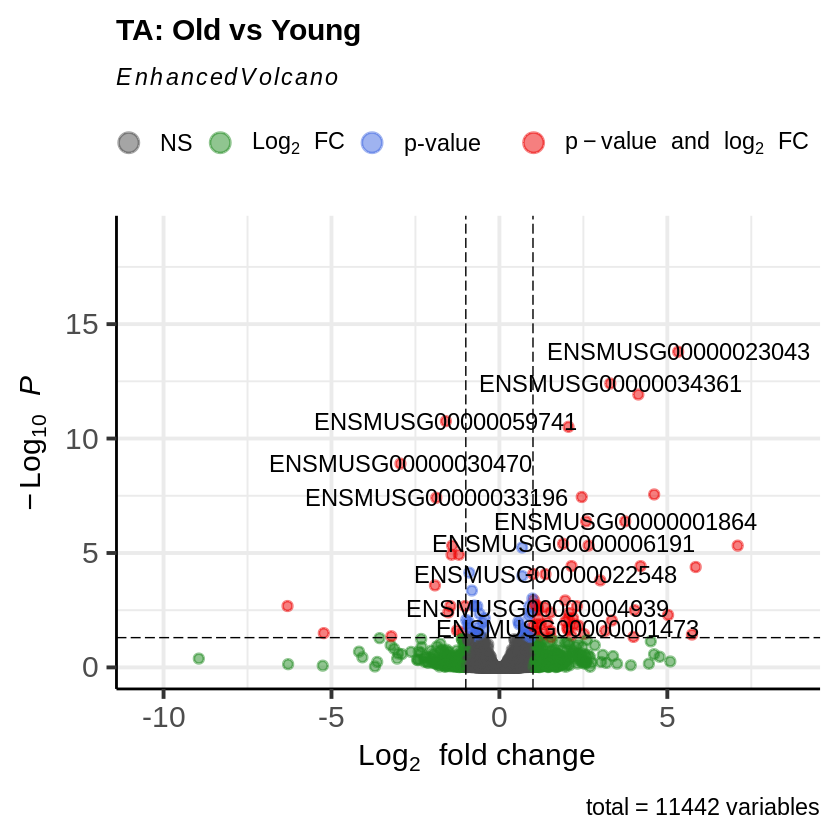

In [19]:
EnhancedVolcano(
    res_ta_df,
    lab = res_ta_df$X,
    x = "log2FoldChange",
    y = "padj",
    pCutoff = 0.05,
    FCcutoff = 1,
    title = "TA: Old vs Young"
)

In [20]:
png(
"/content/drive/MyDrive/aging-muscle-transcriptomics-case-study/results/volcano/TA_volcano.png",
width = 2200,
height = 1800,
res = 300
)

EnhancedVolcano(
    res_ta_df,
    lab = res_ta_df$X,
    x = "log2FoldChange",
    y = "padj",
    pCutoff = 0.05,
    FCcutoff = 1,
    title = "TA: Old vs Young"
)

dev.off()

agg_record_cf652a0a26d 
                     2